# Geophysical Signal Processing for Seismic Event Detection

## Import Libraries

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

## Generate Synthetic Seismic Data

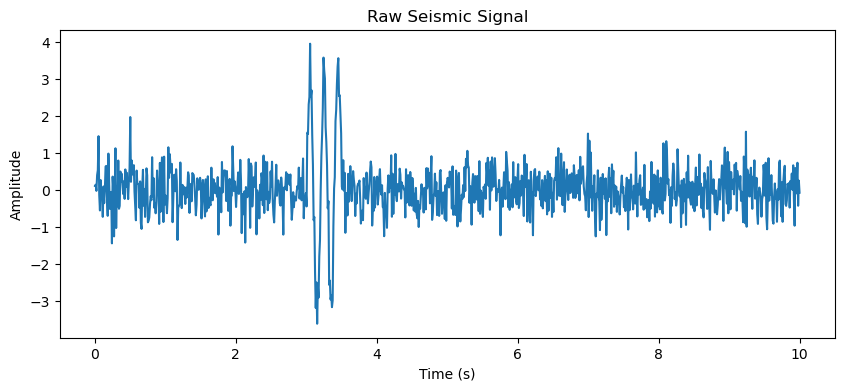

In [72]:
fs = 100
t = np.linspace(0, 10, fs * 10)

signal = np.random.normal(0, 0.5, len(t))

signal[300:350] += 3 * np.sin(2 * np.pi * 5 * t[300:350])

plt.figure(figsize=(10,4))
plt.plot(t, signal)
plt.title("Raw Seismic Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.savefig("results/raw_signal.png")
plt.show()

## Bandpass Filter

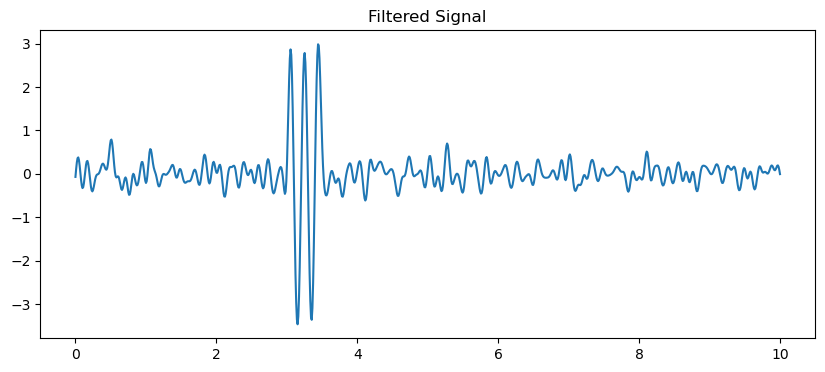

In [73]:
def bandpass_filter(data, lowcut=1, highcut=10, fs=100, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

filtered_signal = bandpass_filter(signal)

plt.figure(figsize=(10,4))
plt.plot(t, filtered_signal)
plt.title("Filtered Signal")
plt.savefig("results/filtered_signal.png")
plt.show()

## STA/LTA Function

In [74]:
def sta_lta(signal, sta_window=20, lta_window=100):

    sta = np.convolve(np.abs(signal),
                      np.ones(sta_window)/sta_window,
                      mode='same')

    lta = np.convolve(np.abs(signal),
                      np.ones(lta_window)/lta_window,
                      mode='same')

    ratio = sta / (lta + 1e-6)

    return ratio

ratio = sta_lta(filtered_signal)

## Plot STA/LTA

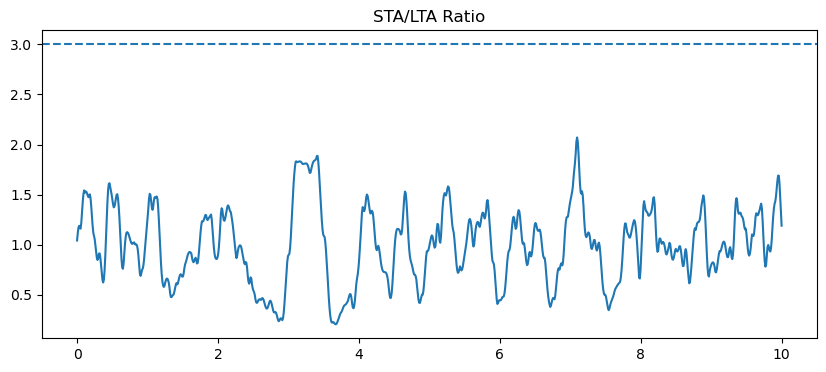

In [75]:
plt.figure(figsize=(10,4))
plt.plot(t, ratio)
plt.axhline(3, linestyle='--')
plt.title("STA/LTA Ratio")
plt.savefig("results/sta_lta_ratio.png")
plt.show()

## Event Detection

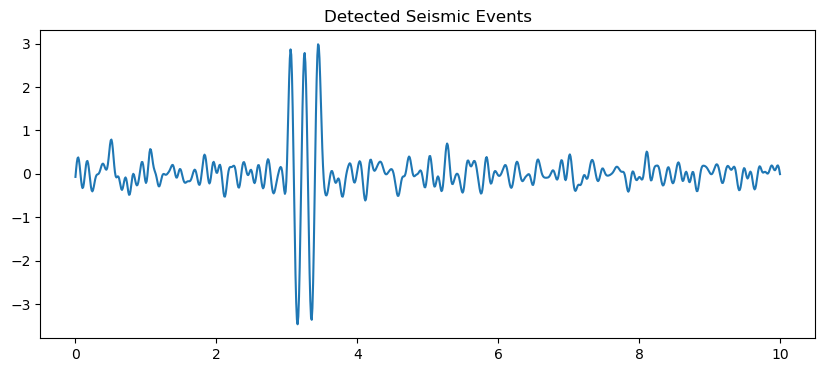

In [76]:
events = np.where(ratio > 3)[0]

plt.figure(figsize=(10,4))
plt.plot(t, filtered_signal)

for e in events[::20]:
    plt.axvline(t[e], linestyle='--')

plt.title("Detected Seismic Events")
plt.savefig("results/sta_lta_ratio.png")
plt.show()

## Conclusion

In [77]:
print("""
Conclusion:
The seismic signal was filtered using a bandpass filter.
STA/LTA analysis successfully detected the synthetic seismic event.
""")


Conclusion:
The seismic signal was filtered using a bandpass filter.
STA/LTA analysis successfully detected the synthetic seismic event.

